In [29]:
import nltk 

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [30]:
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords 
from nltk.stem import WordNetLemmatizer

In [31]:
df = pd.read_csv("all_kindle_review .csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [32]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'asin', 'helpful', 'rating', 'reviewText',
       'reviewTime', 'reviewerID', 'reviewerName', 'summary',
       'unixReviewTime'],
      dtype='object')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    12000 non-null  int64 
 1   Unnamed: 0      12000 non-null  int64 
 2   asin            12000 non-null  object
 3   helpful         12000 non-null  object
 4   rating          12000 non-null  int64 
 5   reviewText      12000 non-null  object
 6   reviewTime      12000 non-null  object
 7   reviewerID      12000 non-null  object
 8   reviewerName    11962 non-null  object
 9   summary         11998 non-null  object
 10  unixReviewTime  12000 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 1.0+ MB


In [34]:
df1 = df.copy()

In [35]:
df1 = df1[['reviewText','rating']]

In [36]:
df1.isnull().sum()

reviewText    0
rating        0
dtype: int64

In [37]:
df1.drop_duplicates(inplace=True)

In [38]:
def normalize_text(text):
    text = str(text).lower()

    text = re.sub(r'\d+','',text)

    text = text.translate(
        str.maketrans('','',string.punctuation)
    )

    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [39]:
df1['normalized_text'] = df1['reviewText'].apply(normalize_text)

In [40]:
df1['tokens'] = df1['normalized_text'].apply(word_tokenize)

In [41]:
stop_words = set(stopwords.words('english'))

In [42]:
df1['tokens_no_stopwords'] = df1['tokens'].apply(
    lambda words: [
        word for word in words 
        if word not in stop_words
    ]
)

In [43]:
lemmatizer = WordNetLemmatizer()

In [44]:
df1['lemmatized_tokens'] = df1['tokens_no_stopwords'].apply(
    lambda words: [
        lemmatizer.lemmatize(word)
        for word in words
    ]
)

In [45]:
df1['processed_text'] = df1['lemmatized_tokens'].apply(
    lambda words:' '.join(words)
)

In [46]:
def sentiment_label(rating):
    if rating >= 4:
        return "positive"

    elif rating == 3:
        return "neutral"

    else:
        return "negative"

In [47]:
df1['sentiment'] = df1['rating'].apply(sentiment_label)

In [48]:
df1[['reviewText','processed_text','sentiment']].head()

,reviewText,processed_text,sentiment
0,"Jace Rankin may be short, but he's nothing to ...",jace rankin may short he nothing mess man haul...,neutral
1,Great short read. I didn't want to put it dow...,great short read didnt want put read one sitti...,positive
2,I'll start by saying this is the first of four...,ill start saying first four book wasnt expecti...,neutral
3,Aggie is Angela Lansbury who carries pocketboo...,aggie angela lansbury carry pocketbook instead...,neutral
4,I did not expect this type of book to be in li...,expect type book library pleased find price right,positive


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

def get_sentiment(rating):
    if rating <= 2: return 'negative'
    if rating == 3: return 'neutral'
    return 'positive'

df1['sentiment'] = df1['rating'].apply(get_sentiment)

X = df1['processed_text']
y = df1['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
svm_model = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', SVC(class_weight='balanced'))
])

param_grid = {
    'tfidf__max_features': [1000, 5000],
    'clf__C': [0.1, 1, 10],
    'clf__kernel': ['linear', 'rbf']
}

In [52]:
grid_search = GridSearchCV(
    svm_model,
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("Starting Hyperparameter Tuning...")
grid_search.fit(X_train, y_train)

# Capture the best model found
svm_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'clf__C': 1, 'clf__kernel': 'rbf', 'tfidf__max_features': 5000}


In [ ]:
y_pred = svm_model.predict(X_test)

print("First 10 predictions:", y_pred[:10])
print("Number of predictions:", len(y_pred))

First 10 predictions: ['positive' 'negative' 'negative' 'negative' 'negative' 'positive'
 'negative' 'positive' 'positive' 'positive']
Number of predictions: 2400


In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.77      0.80      0.78       803
     neutral       0.44      0.20      0.27       387
    positive       0.77      0.89      0.82      1210

    accuracy                           0.74      2400
   macro avg       0.66      0.63      0.63      2400
weighted avg       0.72      0.74      0.72      2400



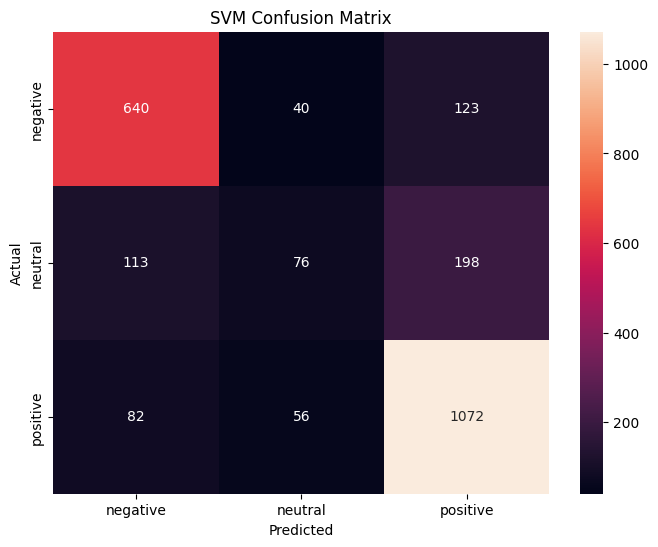

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Ensure your labels are strings and consistent
label_order = ['negative', 'neutral', 'positive']

# 2. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=label_order)

# 3. Plot it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket', 
            xticklabels=label_order, 
            yticklabels=label_order)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')
plt.show()